### 5 · Evaluation — CMS3 Debugging Assistant

This notebook evaluates the CMS3 log-debugging pipeline on a small golden dataset built from the sample journey logs.

### What you will measure
```
1. Retrieval scope hit      → did we retrieve evidence from the right customer / page?
2. Answer keyword coverage  → did the answer mention the expected facts?
3. LLM judge groundedness   → is the answer supported by the retrieved logs?
4. Abstention behavior      → does the system avoid inventing answers when evidence is missing?
```

This sample dataset is best for route explanation and condition tracing. It does not contain real failure events, so one eval case explicitly checks that the system says it lacks enough evidence.


In [9]:
import json
import os
import re
from datetime import datetime
from pathlib import Path

from dotenv import load_dotenv
from flashrank import Ranker
from langchain_community.document_compressors import FlashrankRerank
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone

# Load environment variables from the project root.
NOTEBOOK_DIR = Path.cwd()
load_dotenv(dotenv_path=NOTEBOOK_DIR.parent / ".env", override=True)

EMBEDDING_MODEL = "text-embedding-3-small"
ANSWER_MODEL = "gpt-4o"
JUDGE_MODEL = "gpt-4o-mini"
INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "move-mind-ai")
INDEX_HOST = os.getenv("PINECONE_INDEX_HOST")
NAMESPACE = os.getenv("PINECONE_NAMESPACE", "cms3-logs")
host_label = INDEX_HOST if INDEX_HOST else "<not set>"

required_env = ["OPENAI_API_KEY", "PINECONE_API_KEY"]
missing = [key for key in required_env if not os.getenv(key)]
if missing:
    raise ValueError(f"Missing required environment variables: {missing}")

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
index = pc.Index(host=INDEX_HOST) if INDEX_HOST else pc.Index(INDEX_NAME)
vectorstore = PineconeVectorStore(
    index=index, embedding=embeddings, namespace=NAMESPACE
)
answer_llm = ChatOpenAI(model=ANSWER_MODEL, temperature=0)
judge_llm = ChatOpenAI(model=JUDGE_MODEL, temperature=0)
reranker = FlashrankRerank(client=Ranker(model_name="ms-marco-TinyBERT-L-2-v2"))

print(f"Connected to Pinecone index: {INDEX_NAME}")
print(f"Namespace: {NAMESPACE}")
print(f"Host override: {host_label}")

Connected to Pinecone index: move-mind-ai
Namespace: cms3-logs
Host override: https://move-mind-ai-g57210f.svc.aped-4627-b74a.pinecone.io


---
### Step 1 — Retrieval and Answer Helpers

The eval notebook uses the same retrieval pattern as the app and the LangGraph notebook: scope by business key, combine summary and event chunks, rerank, then answer.


In [10]:
CID_PATTERN = re.compile(r"\bCID\s*[:#-]?\s*(\d+)\b", re.IGNORECASE)
PAGE_PATTERN = re.compile(r"(/[A-Za-z0-9._/-]+)")
ABSTAIN_PHRASES = [
    "don't have enough information",
    "do not have enough information",
    "not enough information",
    "no evidence",
]


def extract_customer_id(query: str) -> str | None:
    match = CID_PATTERN.search(query)
    return match.group(1) if match else None


def extract_page_path(query: str) -> str | None:
    match = PAGE_PATTERN.search(query)
    return match.group(1) if match else None


def build_scope_filter(question: str) -> dict | None:
    metadata_filter = {}
    customer_id = extract_customer_id(question)
    page_path = extract_page_path(question)
    if customer_id:
        metadata_filter["customer_id"] = customer_id
    if page_path:
        metadata_filter["page_path"] = page_path
    return metadata_filter or None


def hybrid_retrieve(
    question: str, *, k_summary: int = 2, k_events: int = 8
) -> list[Document]:
    base_filter = build_scope_filter(question) or {}
    summary_filter = {"chunk_type": "execution_summary"}
    if "customer_id" in base_filter:
        summary_filter["customer_id"] = base_filter["customer_id"]
    event_filter = {"chunk_type": "event", **base_filter}

    summary_docs = vectorstore.similarity_search(
        question, k=k_summary, filter=summary_filter
    )
    event_docs = vectorstore.similarity_search(
        question, k=k_events, filter=event_filter
    )

    unique_docs = []
    seen = set()
    for doc in summary_docs + event_docs:
        key = (doc.page_content, json.dumps(doc.metadata, sort_keys=True, default=str))
        if key in seen:
            continue
        seen.add(key)
        unique_docs.append(doc)
    return unique_docs


ANSWER_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a CMS3 debugging assistant. Answer using ONLY the provided logs. "
            "If the logs do not contain enough evidence, say so clearly and do not guess.\n\nContext:\n{context}",
        ),
        ("human", "{question}"),
    ]
)

answer_chain = ANSWER_PROMPT | answer_llm | StrOutputParser()


def format_context(docs: list[Document]) -> str:
    return "\n\n---\n\n".join(
        f"[chunk_type={d.metadata.get('chunk_type')} | cid={d.metadata.get('customer_id')} | page={d.metadata.get('page_path')}]\n{d.page_content}"
        for d in docs
    )


def run_debug_pipeline(question: str) -> dict:
    retrieved_docs = hybrid_retrieve(question)
    if not retrieved_docs:
        reranked_docs = []
    else:
        reranked_docs = reranker.compress_documents(retrieved_docs, question)
    context = format_context(reranked_docs)
    answer = answer_chain.invoke({"question": question, "context": context})
    return {
        "question": question,
        "retrieved_docs": retrieved_docs,
        "reranked_docs": reranked_docs,
        "answer": answer,
    }


print("Evaluation helpers ready.")

Evaluation helpers ready.


---
### Step 2 — Golden Evaluation Dataset

The sample logs mainly support journey explanation and condition tracing, so the golden questions focus on those use cases.


In [11]:
EVAL_DATASET = [
    {
        "question": "For CID 7093495, what happened after /ccflownew/move-scope?",
        "ground_truth": "After move-scope, the journey moved through check-ist-flow, conditions, next, items, junk-option, quote, pricing, conditions, and booking.",
        "expected_keywords": ["check-ist-flow", "conditions", "items", "booking"],
        "expected_metadata": {"customer_id": "7093495"},
        "should_abstain": False,
    },
    {
        "question": "For CID 7093495, which UI condition evaluated to true on /ccflownew/date?",
        "ground_truth": "The condition !{{moveDate}} evaluated to true and targeted check-falt-rate-date.",
        "expected_keywords": ["!{{moveDate}}", "true", "check-falt-rate-date"],
        "expected_metadata": {"customer_id": "7093495", "page_path": "/ccflownew/date"},
        "should_abstain": False,
    },
    {
        "question": "For CID 7093495, which page was entered right after /ccflownew/returning-customer?",
        "ground_truth": "The next entered page was /ccflownew/check-skill-set-flat-rate.",
        "expected_keywords": ["/ccflownew/check-skill-set-flat-rate"],
        "expected_metadata": {"customer_id": "7093495"},
        "should_abstain": False,
    },
    {
        "question": "For CID 7093495, why did it end up on /ccflownew/quote/booking?",
        "ground_truth": "The logs show the journey progressed through the quote flow and reached quote booking after prior route transitions and condition checks in that path.",
        "expected_keywords": ["quote/booking", "condition", "journey"],
        "expected_metadata": {
            "customer_id": "7093495",
            "page_path": "/ccflownew/quote/booking",
        },
        "should_abstain": False,
    },
    {
        "question": "For CID 44456, why are we seeing a failure?",
        "ground_truth": "The sample dataset does not contain failure evidence for CID 44456, so the system should say it lacks enough information.",
        "expected_keywords": [],
        "expected_metadata": None,
        "should_abstain": True,
    },
]

print(f"Eval dataset size: {len(EVAL_DATASET)}")
for i, item in enumerate(EVAL_DATASET, start=1):
    print(f"[{i}] {item['question']}")

Eval dataset size: 5
[1] For CID 7093495, what happened after /ccflownew/move-scope?
[2] For CID 7093495, which UI condition evaluated to true on /ccflownew/date?
[3] For CID 7093495, which page was entered right after /ccflownew/returning-customer?
[4] For CID 7093495, why did it end up on /ccflownew/quote/booking?
[5] For CID 44456, why are we seeing a failure?


---
### Step 3 — Run the Pipeline on Every Eval Question

We capture both the answer and the reranked evidence so we can score retrieval and generation separately.


In [12]:
eval_results = []
for entry in EVAL_DATASET:
    result = run_debug_pipeline(entry["question"])
    result.update(entry)
    eval_results.append(result)
    print(f"✓ {entry['question']}")

print(f"\nCollected {len(eval_results)} eval results.")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ For CID 7093495, what happened after /ccflownew/move-scope?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ For CID 7093495, which UI condition evaluated to true on /ccflownew/date?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ For CID 7093495, which page was entered right after /ccflownew/returning-customer?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ For CID 7093495, why did it end up on /ccflownew/quote/booking?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ For CID 44456, why are we seeing a failure?

Collected 5 eval results.


---
### Step 4 — Deterministic Checks

These checks do not use an LLM. They give you a fast way to catch obvious regressions before spending more tokens on a judge.


In [13]:
def retrieval_scope_hit(result: dict) -> bool | None:
    expected_metadata = result.get("expected_metadata")
    if not expected_metadata:
        return None

    for doc in result["reranked_docs"]:
        metadata = doc.metadata
        if all(metadata.get(key) == value for key, value in expected_metadata.items()):
            return True
    return False


def answer_keyword_coverage(result: dict) -> float | None:
    keywords = result.get("expected_keywords", [])
    if not keywords:
        return None

    answer_lower = result["answer"].lower()
    hits = sum(1 for keyword in keywords if keyword.lower() in answer_lower)
    return hits / len(keywords)


def abstain_behavior_ok(result: dict) -> bool | None:
    if not result.get("should_abstain"):
        return None
    answer_lower = result["answer"].lower()
    return any(phrase in answer_lower for phrase in ABSTAIN_PHRASES)


for result in eval_results:
    result["retrieval_scope_hit"] = retrieval_scope_hit(result)
    result["keyword_coverage"] = answer_keyword_coverage(result)
    result["abstain_ok"] = abstain_behavior_ok(result)

print(f"{'Question':<68} {'Scope':>8} {'Keywords':>10} {'Abstain':>10}")
print("-" * 100)
for result in eval_results:
    scope = result["retrieval_scope_hit"]
    keyword_cov = result["keyword_coverage"]
    abstain = result["abstain_ok"]
    scope_label = "-" if scope is None else str(scope)
    keyword_label = "-" if keyword_cov is None else f"{keyword_cov:.2f}"
    abstain_label = "-" if abstain is None else str(abstain)
    print(
        f"{result['question'][:66]:<68} {scope_label:>8} {keyword_label:>10} {abstain_label:>10}"
    )

Question                                                                Scope   Keywords    Abstain
----------------------------------------------------------------------------------------------------
For CID 7093495, what happened after /ccflownew/move-scope?              True       0.25          -
For CID 7093495, which UI condition evaluated to true on /ccflowne       True       0.67          -
For CID 7093495, which page was entered right after /ccflownew/ret       True       1.00          -
For CID 7093495, why did it end up on /ccflownew/quote/booking?          True       0.67          -
For CID 44456, why are we seeing a failure?                                 -          -      False


---
### Step 5 — LLM Judge for Groundedness and Usefulness

The deterministic checks are good for smoke tests. The LLM judge adds a more realistic quality read on whether the answer is grounded in the retrieved logs and whether it actually helps a human debug the issue.


In [14]:
JUDGE_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are evaluating a CMS3 debugging answer. Score it on two dimensions:\n"
            "1. groundedness: 1 if the answer is supported by the retrieved logs, 0 otherwise.\n"
            "2. usefulness: 1 if the answer is practically useful for debugging the question, 0 otherwise.\n"
            "Return only a JSON object with keys groundedness, usefulness, and reason.",
        ),
        (
            "human",
            "Question:\n{question}\n\nGround truth:\n{ground_truth}\n\nRetrieved context:\n{context}\n\nAnswer:\n{answer}",
        ),
    ]
)

judge_chain = JUDGE_PROMPT | judge_llm | StrOutputParser()


def parse_json_response(text: str) -> dict:
    cleaned = text.strip()
    if cleaned.startswith("```json"):
        cleaned = cleaned.removeprefix("```json").removesuffix("```").strip()
    elif cleaned.startswith("```"):
        cleaned = cleaned.removeprefix("```").removesuffix("```").strip()
    return json.loads(cleaned)


for result in eval_results:
    context = format_context(result["reranked_docs"])
    judge_raw = judge_chain.invoke(
        {
            "question": result["question"],
            "ground_truth": result["ground_truth"],
            "context": context,
            "answer": result["answer"],
        }
    )
    result["judge"] = parse_json_response(judge_raw)
    print(f"✓ judged: {result['question'][:60]}...")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ judged: For CID 7093495, what happened after /ccflownew/move-scope?...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ judged: For CID 7093495, which UI condition evaluated to true on /cc...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ judged: For CID 7093495, which page was entered right after /ccflown...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ judged: For CID 7093495, why did it end up on /ccflownew/quote/booki...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✓ judged: For CID 44456, why are we seeing a failure?...


In [15]:
groundedness_scores = [result["judge"]["groundedness"] for result in eval_results]
usefulness_scores = [result["judge"]["usefulness"] for result in eval_results]
scope_hits = [
    result["retrieval_scope_hit"]
    for result in eval_results
    if result["retrieval_scope_hit"] is not None
]
keyword_scores = [
    result["keyword_coverage"]
    for result in eval_results
    if result["keyword_coverage"] is not None
]
abstain_scores = [
    result["abstain_ok"] for result in eval_results if result["abstain_ok"] is not None
]

print("=" * 100)
print("CMS3 EVALUATION SCORECARD")
print("=" * 100)
print(
    f"Average groundedness:      {sum(groundedness_scores) / len(groundedness_scores):.2f}"
)
print(
    f"Average usefulness:        {sum(usefulness_scores) / len(usefulness_scores):.2f}"
)
print(f"Retrieval scope hit rate:  {sum(scope_hits) / len(scope_hits):.2f}")
print(f"Keyword coverage average:  {sum(keyword_scores) / len(keyword_scores):.2f}")
if abstain_scores:
    print(f"Abstention success rate:   {sum(abstain_scores) / len(abstain_scores):.2f}")
print("=" * 100)

print(f"\n{'Question':<68} {'Grounded':>8} {'Useful':>8}")
print("-" * 100)
for result in eval_results:
    judge = result["judge"]
    print(
        f"{result['question'][:66]:<68} {judge['groundedness']:>8} {judge['usefulness']:>8}"
    )

CMS3 EVALUATION SCORECARD
Average groundedness:      1.00
Average usefulness:        1.00
Retrieval scope hit rate:  1.00
Keyword coverage average:  0.65
Abstention success rate:   0.00

Question                                                             Grounded   Useful
----------------------------------------------------------------------------------------------------
For CID 7093495, what happened after /ccflownew/move-scope?                 1        1
For CID 7093495, which UI condition evaluated to true on /ccflowne          1        1
For CID 7093495, which page was entered right after /ccflownew/ret          1        1
For CID 7093495, why did it end up on /ccflownew/quote/booking?             1        1
For CID 44456, why are we seeing a failure?                                 1        1


---
### Step 6 — Visualize the Eval Metrics

The scorecard is useful for logging, but charts make it easier to spot weak areas quickly. This step shows both overall metric health and per-question behavior.


,metric,score
0,Groundedness,1.00
1,Usefulness,1.00
2,Scope Hit Rate,1.00
3,Keyword Coverage,0.65
4,Abstention,0.00


ValueError: could not convert string to float: '-'

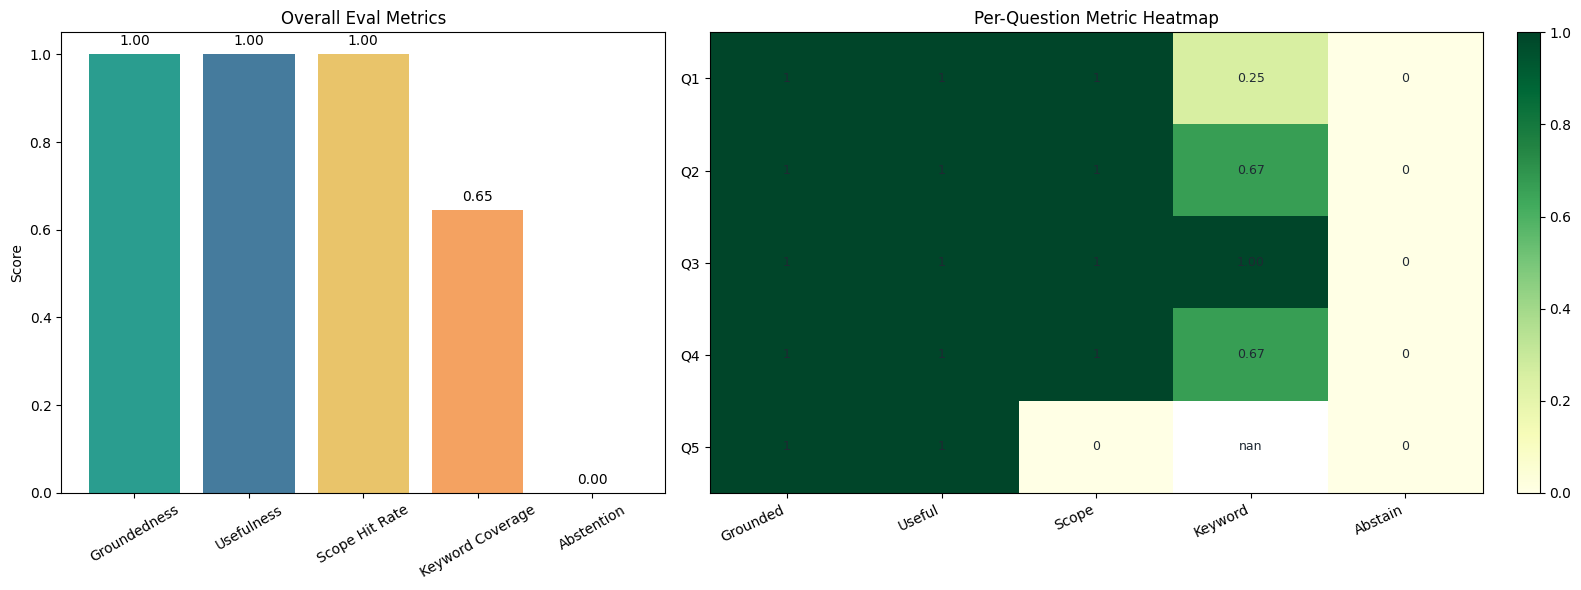

Question key:
Q1: For CID 7093495, what happened after /ccflownew/move-scope?
Q2: For CID 7093495, which UI condition evaluated to true on /ccflownew/date?
Q3: For CID 7093495, which page was entered right after /ccflownew/returning-customer?
Q4: For CID 7093495, why did it end up on /ccflownew/quote/booking?
Q5: For CID 44456, why are we seeing a failure?


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

summary_metrics = {
    "Groundedness": sum(groundedness_scores) / len(groundedness_scores),
    "Usefulness": sum(usefulness_scores) / len(usefulness_scores),
    "Scope Hit Rate": sum(scope_hits) / len(scope_hits),
    "Keyword Coverage": sum(keyword_scores) / len(keyword_scores),
}
if abstain_scores:
    summary_metrics["Abstention"] = sum(abstain_scores) / len(abstain_scores)

summary_df = pd.DataFrame(
    {"metric": list(summary_metrics.keys()), "score": list(summary_metrics.values())}
)

eval_df = pd.DataFrame(
    [
        {
            "question_label": f"Q{i + 1}",
            "question": result["question"],
            "groundedness": result["judge"]["groundedness"],
            "usefulness": result["judge"]["usefulness"],
            "retrieval_scope_hit": result["retrieval_scope_hit"],
            "keyword_coverage": result["keyword_coverage"],
            "abstain_ok": result["abstain_ok"],
        }
        for i, result in enumerate(eval_results)
    ]
)

display(
    summary_df.style.format({"score": "{:.2f}"}).background_gradient(
        cmap="YlGn", subset=["score"]
    )
)

display_columns = [
    "question_label",
    "question",
    "groundedness",
    "usefulness",
    "retrieval_scope_hit",
    "keyword_coverage",
    "abstain_ok",
]
display(
    eval_df[display_columns]
    .fillna("-")
    .style.format({"keyword_coverage": "{:.2f}"}, na_rep="-")
    .background_gradient(
        cmap="YlGn", subset=["groundedness", "usefulness", "keyword_coverage"]
    )
)

plot_df = eval_df.copy()
plot_df["retrieval_scope_hit"] = plot_df["retrieval_scope_hit"].fillna(0)
plot_df["abstain_ok"] = plot_df["abstain_ok"].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})

axes[0].bar(
    summary_df["metric"],
    summary_df["score"],
    color=["#2a9d8f", "#457b9d", "#e9c46a", "#f4a261", "#e76f51"][: len(summary_df)],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].set_title("Overall Eval Metrics")
axes[0].tick_params(axis="x", rotation=30)
for idx, score in enumerate(summary_df["score"]):
    axes[0].text(idx, score + 0.02, f"{score:.2f}", ha="center", fontsize=10)

heatmap_columns = [
    "groundedness",
    "usefulness",
    "retrieval_scope_hit",
    "keyword_coverage",
    "abstain_ok",
]
heatmap_df = plot_df[heatmap_columns].astype(float)
im = axes[1].imshow(heatmap_df.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(heatmap_columns)))
axes[1].set_xticklabels(
    ["Grounded", "Useful", "Scope", "Keyword", "Abstain"], rotation=25, ha="right"
)
axes[1].set_yticks(range(len(plot_df)))
axes[1].set_yticklabels(plot_df["question_label"])
axes[1].set_title("Per-Question Metric Heatmap")

for row in range(len(plot_df)):
    for col in range(len(heatmap_columns)):
        value = heatmap_df.iloc[row, col]
        label = (
            f"{value:.2f}"
            if heatmap_columns[col] == "keyword_coverage"
            else str(int(value))
        )
        axes[1].text(
            col, row, label, ha="center", va="center", color="#1f2933", fontsize=9
        )

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Question key:")
for row in eval_df[["question_label", "question"]].itertuples(index=False):
    print(f"{row.question_label}: {row.question}")

---
### Step 7 — Save the Eval Run

Saving the eval artifact makes it possible to compare changes across chunking, retrieval, memory, and reranking experiments later.


In [17]:
output = {
    "timestamp": datetime.now().isoformat(),
    "config": {
        "embedding_model": EMBEDDING_MODEL,
        "answer_model": ANSWER_MODEL,
        "judge_model": JUDGE_MODEL,
        "index_name": INDEX_NAME,
        "namespace": NAMESPACE,
    },
    "summary": {
        "avg_groundedness": sum(groundedness_scores) / len(groundedness_scores),
        "avg_usefulness": sum(usefulness_scores) / len(usefulness_scores),
        "retrieval_scope_hit_rate": sum(scope_hits) / len(scope_hits),
        "avg_keyword_coverage": sum(keyword_scores) / len(keyword_scores),
        "abstention_success_rate": None
        if not abstain_scores
        else sum(abstain_scores) / len(abstain_scores),
    },
    "results": [
        {
            "question": result["question"],
            "ground_truth": result["ground_truth"],
            "answer": result["answer"],
            "retrieval_scope_hit": result["retrieval_scope_hit"],
            "keyword_coverage": result["keyword_coverage"],
            "abstain_ok": result["abstain_ok"],
            "judge": result["judge"],
        }
        for result in eval_results
    ],
}

output_path = NOTEBOOK_DIR.parent / "data" / "eval" / "cms3_eval_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(json.dumps(output, indent=2))
print(f"Saved eval results to: {output_path}")

Saved eval results to: /Users/sauravmajumdar/Developer/AI/move-mind-ai/data/eval/cms3_eval_results.json


---
### Takeaways

- The current sample is strong for route and condition evals, but weak for failure-debugging evals because it has no real errors.
- Retrieval quality for this feature is not only about vector similarity; it is also about whether the evidence is scoped to the right customer and page.
- A good debugging eval should reward both grounded answers and correct abstention when evidence is missing.

Once you collect failing journeys, this notebook can expand to failure-root-cause evals instead of only route-tracing evals.
